<a href="https://colab.research.google.com/github/fzkmdly/AirBnb/blob/main/AirBnbUS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install psycopg2 sqlalchemy
%pip install pandas as pd
%pip install numpy as np
%pip install matplotlib.pyplot as plt
%pip install seaborn as sns
%pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot


Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("kritikseth/us-airbnb-open-data")

# print("Path to dataset files:", path)

load_dotenv()

connection = psycopg2.connect(
    host=os.environ.get("DB_HOST", "localhost"),
    database=os.environ.get("DB_NAME", "airbnb"),
    user=os.environ.get("DB_USER", "postgres"),
    password=os.environ.get("DB_PASSWORD"),
    port=os.environ.get("DB_PORT", "5432"),
)

In [5]:
query = """
SELECT table_name 
FROM information_schema.tables 
WHERE table_schema = 'public'
"""
tables_df = pd.read_sql_query(query, connection)
print(tables_df)

                 table_name
0        airbnb_kab_bandung
1  airbnb_kab_bandung_barat
2        airbnb_kota_cimahi
3    airbnb_bandungraya_all
4       airbnb_kota_bandung
5                 airbnb_us


C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_12968\1048451943.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  tables_df = pd.read_sql_query(query, connection)


In [6]:
query = "SELECT * FROM airbnb_us"

df = pd.read_sql_query(query, connection)

df

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_12968\2566251179.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city
0,958,"Bright, Modern Garden Unit - 1BR/1BTH",1169,Holly,,Western Addition,37.770280,-122.433170,Entire home/apt,202,2,383,2023-02-19,2.31,1,128,59,San Francisco
1,5858,Creative Sanctuary,8904,Philip And Tania,,Bernal Heights,37.744740,-122.420890,Entire home/apt,235,30,111,2017-08-06,0.66,1,365,0,San Francisco
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,,Haight Ashbury,37.765550,-122.452130,Private room,56,32,9,2022-10-27,0.09,13,365,1,San Francisco
3,8339,Historic Alamo Square Victorian,24215,Rosy,,Western Addition,37.775640,-122.436420,Entire home/apt,575,9,28,2019-06-28,0.17,2,365,0,San Francisco
4,8739,"Mission Sunshine, with Private Bath",7149,Ivan & Wendy,,Mission,37.760300,-122.421970,Private room,110,1,770,2023-02-25,4.65,2,159,34,San Francisco
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232142,849230448624862502,Private Half Moon Bay Oasis By Pillar Point Be...,29395385,Khalid,,Unincorporated Areas,37.506165,-122.476190,Entire home/apt,389,2,0,,NaN,1,365,0,San Mateo County
232143,850805127216414630,Home near SFO,440957696,Christina,,San Bruno,37.623630,-122.426570,Entire home/apt,158,1,0,,NaN,1,364,0,San Mateo County
232144,851562104616413652,Modern New Private Studio in SFO,41574587,Vality,,South San Francisco,37.655663,-122.413130,Entire home/apt,97,1,0,,NaN,32,359,0,San Mateo County
232145,851792795339759410,Lux Bedroom with a Shared Bath near SFO,73133543,Stephannie,,South San Francisco,37.644790,-122.454216,Private room,62,2,0,,NaN,3,67,0,San Mateo County


# Data Cleaning

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232147 entries, 0 to 232146
Data columns (total 18 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              232147 non-null  int64  
 1   name                            232147 non-null  object 
 2   host_id                         232147 non-null  int64  
 3   host_name                       232147 non-null  object 
 4   neighbourhood_group             232147 non-null  object 
 5   neighbourhood                   232147 non-null  object 
 6   latitude                        232147 non-null  float64
 7   longitude                       232147 non-null  float64
 8   room_type                       232147 non-null  object 
 9   price                           232147 non-null  int64  
 10  minimum_nights                  232147 non-null  int64  
 11  number_of_reviews               232147 non-null  int64  
 12  last_review     

In [8]:
df.describe().style.format(lambda x: f'{x:.2f}')

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,232147.00,232147.00,232147.00,232147.00,232147.00,232147.00,232147.00,183062.00,232147.00,232147.00,232147.00
mean,258458021912406304.00,158224798.87,36.61,-98.30,259.47,13.50,40.92,1.64,29.88,180.99,11.69
std,346598536640871936.00,158716378.00,5.13,19.71,1024.65,27.92,80.65,1.91,106.01,134.72,20.60
min,6.00,23.00,25.96,-123.09,0.00,1.00,0.00,0.01,1.00,0.00,0.00
25%,26388957.50,22992416.00,33.98,-118.32,91.00,2.00,1.00,0.31,1.00,52.00,0.00
50%,48963066.00,100578284.00,36.19,-97.73,149.00,3.00,9.00,1.00,2.00,175.00,3.00
75%,663301392245389184.00,268693041.50,40.72,-77.03,250.00,30.00,43.00,2.42,10.00,321.00,16.00
max,858101367585572736.00,506938352.00,47.73,-71.00,100000.00,1250.00,3091.00,101.42,1003.00,365.00,1314.00


In [9]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                           0
reviews_per_month                 49085
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
city                                  0
dtype: int64

In [10]:
df.groupby('city')['neighbourhood_group'].apply(lambda x: x.isna().mean())

city
Asheville             0.0
Austin                0.0
Boston                0.0
Broward County        0.0
Cambridge             0.0
Chicago               0.0
Clark County          0.0
Columbus              0.0
Denver                0.0
Jersey City           0.0
Los Angeles           0.0
Nashville             0.0
New Orleans           0.0
New York City         0.0
Oakland               0.0
Pacific Grove         0.0
Portland              0.0
Rhode Island          0.0
Salem                 0.0
San Diego             0.0
San Francisco         0.0
San Mateo County      0.0
Santa Clara County    0.0
Santa Cruz County     0.0
Seattle               0.0
Twin Cities MSA       0.0
Washington D.C.       0.0
Name: neighbourhood_group, dtype: float64

In [11]:
df['neighbourhood_group'].unique()

array(['', 'Queens', 'Brooklyn', 'Manhattan', 'Other Cities',
       'Unincorporated Areas', 'City of Los Angeles', 'Bronx',
       'Providence', 'Staten Island', 'Washington', 'Newport', 'Bristol',
       'Kent', 'Capitol Hill', 'Cascade', 'Central Area',
       'Other neighborhoods', 'Delridge', 'Magnolia', 'Beacon Hill',
       'West Seattle', 'Ballard', 'Queen Anne', 'Downtown',
       'Rainier Valley', 'Northgate', 'Lake City', 'University District',
       'Seward Park', 'Interbay'], dtype=object)

In [12]:
df = df.drop(columns=['neighbourhood_group'])

In [13]:
df['has_reviews'] = df['number_of_reviews'] > 0

df

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
0,958,"Bright, Modern Garden Unit - 1BR/1BTH",1169,Holly,Western Addition,37.770280,-122.433170,Entire home/apt,202,2,383,2023-02-19,2.31,1,128,59,San Francisco,True
1,5858,Creative Sanctuary,8904,Philip And Tania,Bernal Heights,37.744740,-122.420890,Entire home/apt,235,30,111,2017-08-06,0.66,1,365,0,San Francisco,True
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,Haight Ashbury,37.765550,-122.452130,Private room,56,32,9,2022-10-27,0.09,13,365,1,San Francisco,True
3,8339,Historic Alamo Square Victorian,24215,Rosy,Western Addition,37.775640,-122.436420,Entire home/apt,575,9,28,2019-06-28,0.17,2,365,0,San Francisco,True
4,8739,"Mission Sunshine, with Private Bath",7149,Ivan & Wendy,Mission,37.760300,-122.421970,Private room,110,1,770,2023-02-25,4.65,2,159,34,San Francisco,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232142,849230448624862502,Private Half Moon Bay Oasis By Pillar Point Be...,29395385,Khalid,Unincorporated Areas,37.506165,-122.476190,Entire home/apt,389,2,0,,NaN,1,365,0,San Mateo County,False
232143,850805127216414630,Home near SFO,440957696,Christina,San Bruno,37.623630,-122.426570,Entire home/apt,158,1,0,,NaN,1,364,0,San Mateo County,False
232144,851562104616413652,Modern New Private Studio in SFO,41574587,Vality,South San Francisco,37.655663,-122.413130,Entire home/apt,97,1,0,,NaN,32,359,0,San Mateo County,False
232145,851792795339759410,Lux Bedroom with a Shared Bath near SFO,73133543,Stephannie,South San Francisco,37.644790,-122.454216,Private room,62,2,0,,NaN,3,67,0,San Mateo County,False


In [14]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                           0
reviews_per_month                 49085
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
city                                  0
has_reviews                           0
dtype: int64

In [15]:
df.dropna(subset=['name', 'host_name'], inplace=True)

In [16]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                           0
reviews_per_month                 49085
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
city                                  0
has_reviews                           0
dtype: int64

# Sanity Check

## Price

In [17]:
df['price'].describe()

count    232147.000000
mean        259.468001
std        1024.645918
min           0.000000
25%          91.000000
50%         149.000000
75%         250.000000
max      100000.000000
Name: price, dtype: float64

In [18]:
df[df['price'] == 0]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
4500,48693144,Hotel Emblem San Francisco,392829961,Emily,Nob Hill,37.790257,-122.410560,Hotel room,0,1,0,,NaN,1,0,0,San Francisco,False
4605,48973911,Hotel Triton San Francisco,394984266,Hotel,Financial District,37.789250,-122.404495,Hotel room,0,1,10,2023-01-29,0.46,1,0,3,San Francisco,True
5079,52498132,"Bedroom, bath and garden",2577011,Sarah,Parkside,37.739330,-122.477920,Private room,0,1,3,2021-11-28,0.18,2,0,0,San Francisco,True
10111,42738808,Capital View Hostel,312293881,Linas,"Downtown, Chinatown, Penn Quarters, Mount Vern...",38.901510,-77.015530,Hotel room,0,31,0,,NaN,1,0,0,Washington D.C.,False
10527,46253554,citizenM Washington DC Capitol,374527046,CitizenM,"Southwest Employment Area, Southwest/Waterfron...",38.882862,-77.019196,Hotel room,0,1,295,2023-02-26,11.49,1,0,146,Washington D.C.,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196650,42740562,Shore Haven Resort Inn,315905144,Shore Haven Resort Inn,Lauderdale By The Sea,26.191640,-80.096830,Hotel room,0,1,0,,NaN,1,0,0,Broward County,False
197872,42535198,The Cabanas Guesthouse & Spa,310483408,Cabanas,Wilton Manors,26.160060,-80.118390,Hotel room,0,1,0,,NaN,1,0,0,Broward County,False
226616,42065556,Inn @ St. Botolph,107268789,Inn @,Back Bay,42.345030,-71.080850,Hotel room,0,91,20,2022-10-02,0.74,1,0,2,Boston,True
226738,46232976,citizenM Boston North Station,374414807,CitizenM,Downtown,42.364790,-71.062500,Hotel room,0,1,497,2023-03-05,18.95,1,0,149,Boston,True


In [19]:
df[df['price'] > 5000]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
375,1059961,KelSoMa 1 Bed & Bath in SoMa,1427845,Laura,South of Market,37.780080,-122.409360,Shared room,10000,35,40,2015-11-27,0.34,1,206,0,San Francisco,True
2219,23269859,Stratford Cozy Cool Queen,173206762,Stratford,Downtown/Civic Center,37.787770,-122.406770,Private room,9999,1,5,2020-02-15,0.08,61,293,0,San Francisco,True
2221,23271162,Stratford Cozy Cool Queen,173206762,Stratford,Downtown/Civic Center,37.786510,-122.409150,Private room,9999,1,5,2019-05-20,0.10,61,293,0,San Francisco,True
2223,23271459,Stratford Cozy Cool Queen,173206762,Stratford,Downtown/Civic Center,37.787450,-122.407140,Hotel room,9999,1,3,2020-02-16,0.06,61,293,0,San Francisco,True
2224,23271549,Stratford Cool Queen,173206762,Stratford,Downtown/Civic Center,37.788160,-122.406970,Private room,9999,1,9,2020-03-02,0.15,61,293,0,San Francisco,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224478,839292502388813097,1-Bedroom Hotel Suite - 1 bed,326084746,Suiteness,Unincorporated Areas,36.117516,-115.188156,Private room,20000,1,0,,NaN,327,119,0,Clark County,False
224504,839729662956412409,1-Bedroom Hotel Suite - 1 bed,326084746,Suiteness,Unincorporated Areas,36.116120,-115.172490,Private room,20000,1,0,,NaN,327,119,0,Clark County,False
229240,12991169,The Atherton Estate Near Stanford,22124692,Jason,Atherton,37.440720,-122.214730,Entire home/apt,5500,2,34,2020-09-10,0.42,1,0,0,San Mateo County,True
229277,10808594,4500 sq. 5x4. Great location.,55954872,Eric,Unincorporated Areas,37.573980,-122.390560,Entire home/apt,5800,3,0,,NaN,1,0,0,San Mateo County,False


In [20]:
df['price'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

0.01      30.0
0.05      46.0
0.25      91.0
0.50     149.0
0.75     250.0
0.95     666.0
0.99    1803.0
Name: price, dtype: float64

In [21]:
df[df['price'] <= 0]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
4500,48693144,Hotel Emblem San Francisco,392829961,Emily,Nob Hill,37.790257,-122.410560,Hotel room,0,1,0,,NaN,1,0,0,San Francisco,False
4605,48973911,Hotel Triton San Francisco,394984266,Hotel,Financial District,37.789250,-122.404495,Hotel room,0,1,10,2023-01-29,0.46,1,0,3,San Francisco,True
5079,52498132,"Bedroom, bath and garden",2577011,Sarah,Parkside,37.739330,-122.477920,Private room,0,1,3,2021-11-28,0.18,2,0,0,San Francisco,True
10111,42738808,Capital View Hostel,312293881,Linas,"Downtown, Chinatown, Penn Quarters, Mount Vern...",38.901510,-77.015530,Hotel room,0,31,0,,NaN,1,0,0,Washington D.C.,False
10527,46253554,citizenM Washington DC Capitol,374527046,CitizenM,"Southwest Employment Area, Southwest/Waterfron...",38.882862,-77.019196,Hotel room,0,1,295,2023-02-26,11.49,1,0,146,Washington D.C.,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196650,42740562,Shore Haven Resort Inn,315905144,Shore Haven Resort Inn,Lauderdale By The Sea,26.191640,-80.096830,Hotel room,0,1,0,,NaN,1,0,0,Broward County,False
197872,42535198,The Cabanas Guesthouse & Spa,310483408,Cabanas,Wilton Manors,26.160060,-80.118390,Hotel room,0,1,0,,NaN,1,0,0,Broward County,False
226616,42065556,Inn @ St. Botolph,107268789,Inn @,Back Bay,42.345030,-71.080850,Hotel room,0,91,20,2022-10-02,0.74,1,0,2,Boston,True
226738,46232976,citizenM Boston North Station,374414807,CitizenM,Downtown,42.364790,-71.062500,Hotel room,0,1,497,2023-03-05,18.95,1,0,149,Boston,True


In [22]:
df[(df['price'] > 0) & (df['price'] < 10)]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews
35312,41126644,Need to get away?? land for Rent for RV or Tent.,76557647,Anthony,Lancaster,34.69046,-118.30069,Entire home/apt,9,1,8,2023-03-06,0.39,1,365,6,Los Angeles,True
166919,19840835,Eco Friendly Tiny Apartment,3440175,James,78702,30.25438,-97.70306,Private room,5,1,1,2017-07-16,0.01,8,0,0,Austin,True
167023,20674436,Hurricane Harvey Refuge ONLY,3594051,Michael,78704,30.23928,-97.74298,Entire home/apt,1,2,2,2017-09-10,0.03,1,0,0,Austin,True


In [23]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR  # pakai 3x (bukan 1.5x) karena harga properti wajar skewed

outliers = df[df['price'] > upper_bound]
print(f"Jumlah outlier: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

Jumlah outlier: 10141 (4.37%)


In [24]:
df = df[(df['price'] > 10)]

In [25]:
cap = df['price'].quantile(0.99)
df['price_capped'] = df['price'].clip(upper=cap)

C:\Users\Faiz Akhmad Daulay\AppData\Local\Temp\ipykernel_12968\3707569700.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['price_capped'] = df['price'].clip(upper=cap)


## Minimum Nights

In [26]:
df['minimum_nights'].describe()

count    232017.000000
mean         13.496692
std          27.923933
min           1.000000
25%           2.000000
50%           3.000000
75%          30.000000
max        1250.000000
Name: minimum_nights, dtype: float64

In [27]:
df[df['minimum_nights'] > 30]

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,city,has_reviews,price_capped
2,8142,Friendly Room Apt. Style -UCSF/USF - San Franc...,21994,Aaron,Haight Ashbury,37.765550,-122.452130,Private room,56,32,9,2022-10-27,0.09,13,365,1,San Francisco,True,56.0
9,12041,Sunny/Sunset view room UCSF/USF - San Francisco,21994,Aaron,Haight Ashbury,37.769010,-122.447010,Private room,65,32,7,2022-06-11,0.05,13,365,1,San Francisco,True,65.0
11,12042,Sunny/Sunset view room UCSF/USF - San Francisco*,21994,Aaron,Haight Ashbury,37.769320,-122.447230,Private room,65,32,5,2015-10-18,0.04,13,365,0,San Francisco,True,65.0
35,511991,2bed2bath Lux Living awesome amenities,723220,Helena,Financial District,37.791380,-122.397610,Entire home/apt,390,31,1,2012-09-14,0.01,1,300,0,San Francisco,True,390.0
38,519796,Lrg Sunny Flat/1 Blk fr Lombard St,2019559,Suzette,Russian Hill,37.801000,-122.424360,Entire home/apt,126,31,79,2018-12-08,0.61,1,270,0,San Francisco,True,126.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231984,792427641211747334,San Mateo Downtown Cozy 1B1B master suite,374807718,Zoe,San Mateo,37.568542,-122.331635,Private room,80,365,0,,NaN,2,364,0,San Mateo County,False,80.0
232016,827702896287845213,1bd/1ba remodeled furnished condo in Crown Colony,498700219,Albert,Daly City,37.663944,-122.462960,Entire home/apt,92,60,0,,NaN,1,314,0,San Mateo County,False,92.0
232060,842500529513572163,"Menlo Park 2br w/ a/c, lounge & w/d, nr Menlo ...",107434423,Blueground,Menlo Park,37.457630,-122.189540,Entire home/apt,269,31,0,,NaN,183,316,0,San Mateo County,False,269.0
232092,846241465100308453,NEW! Daly City Vacation Rental w/ Furnished Patio,126644773,Evolve,Daly City,37.698500,-122.464550,Entire home/apt,161,31,0,,NaN,9,361,0,San Mateo County,False,161.0


In [28]:
df = df[df['minimum_nights'] <= 30]

In [29]:
df[df['minimum_nights'] > 30].value_counts()

Series([], Name: count, dtype: int64)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 211716 entries, 0 to 232146
Data columns (total 19 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              211716 non-null  int64  
 1   name                            211716 non-null  object 
 2   host_id                         211716 non-null  int64  
 3   host_name                       211716 non-null  object 
 4   neighbourhood                   211716 non-null  object 
 5   latitude                        211716 non-null  float64
 6   longitude                       211716 non-null  float64
 7   room_type                       211716 non-null  object 
 8   price                           211716 non-null  int64  
 9   minimum_nights                  211716 non-null  int64  
 10  number_of_reviews               211716 non-null  int64  
 11  last_review                     211716 non-null  object 
 12  reviews_per_month    

# Explanatory Data Analysis

In [31]:
df.groupby('room_type')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
room_type,,,,,,,,
Entire home/apt,153276.0,288.625721,869.664539,11.0,121.0,180.0,296.0,100000.0
Hotel room,875.0,816.667429,1269.143303,22.0,149.0,259.0,1663.0,10000.0
Private room,55491.0,201.322413,1423.562463,12.0,55.0,78.0,120.0,100000.0
Shared room,2074.0,92.156702,363.960888,11.0,30.0,42.5,70.0,10000.0


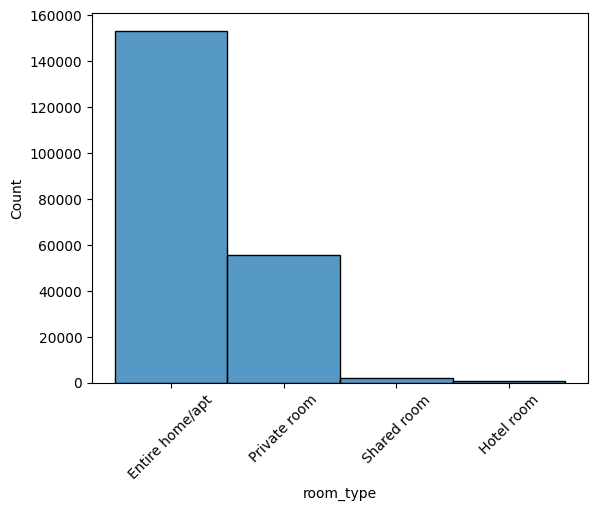

In [32]:
sns.histplot(df, x='room_type')
plt.xticks(rotation=45)
plt.show()

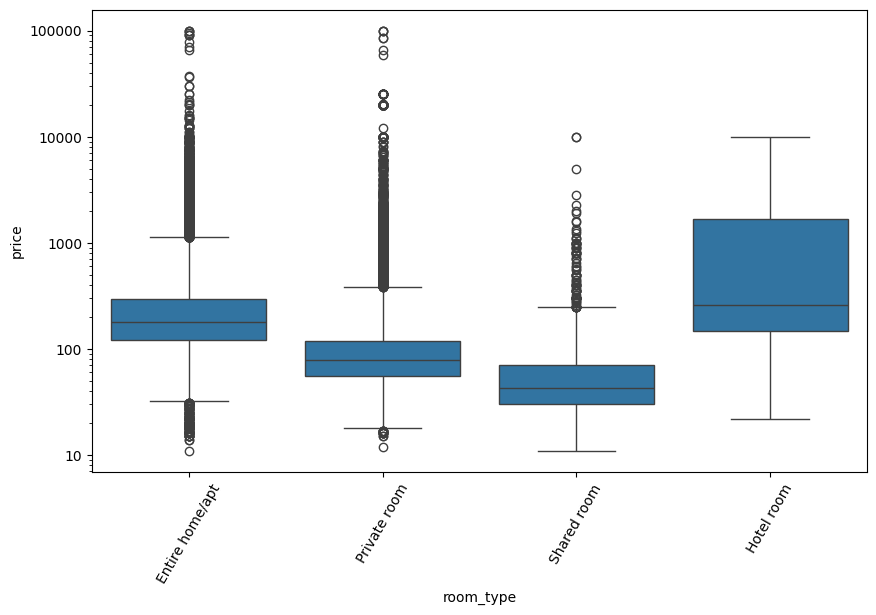

In [33]:
from matplotlib.ticker import ScalarFormatter

# ... your existing code ...
plt.figure(figsize=(10,6))
ax = sns.boxplot(data=df, x='room_type', y='price', log_scale=10)
plt.xticks(rotation=60)

# Change log scale formatting to plain text
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.show()

In [34]:
df.groupby('city')['price'].median().sort_values(ascending=False)

city
Pacific Grove         250.0
Santa Cruz County     250.0
Rhode Island          223.0
Broward County        200.0
Nashville             200.0
San Diego             193.0
Clark County          189.0
Austin                181.0
New Orleans           167.0
Boston                152.0
San Mateo County      150.0
San Francisco         150.0
Los Angeles           148.0
Washington D.C.       147.0
Cambridge             140.0
Asheville             130.0
Seattle               127.0
Twin Cities MSA       125.0
New York City         125.0
Denver                120.0
Jersey City           119.0
Chicago               119.0
Santa Clara County    114.0
Oakland               112.0
Columbus              102.0
Portland              101.0
Salem                 101.0
Name: price, dtype: float64

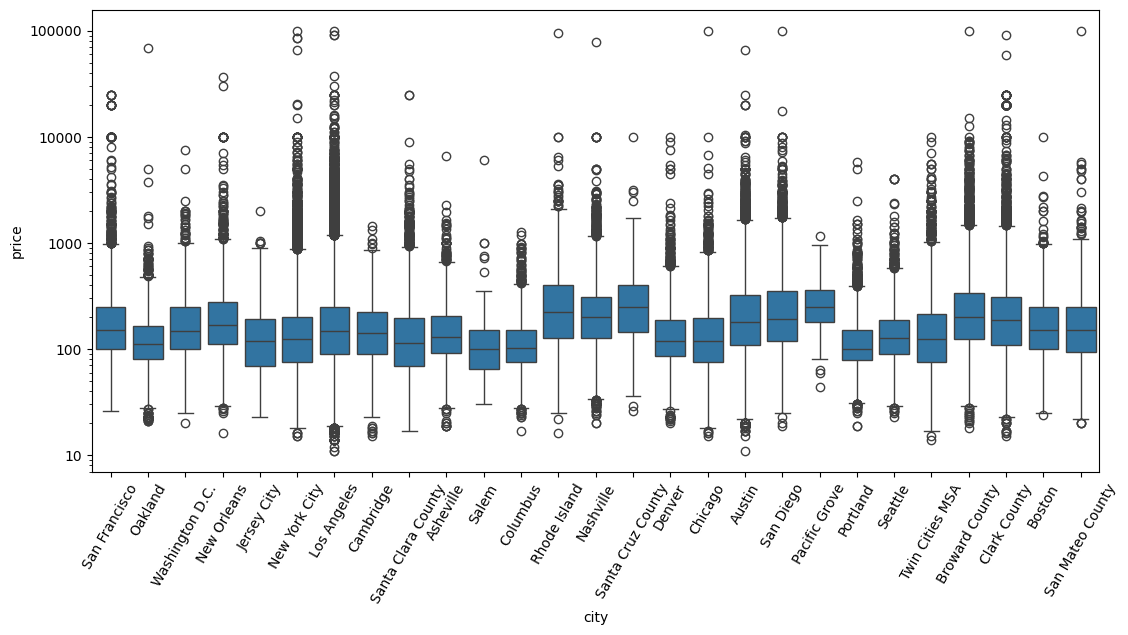

In [35]:
from matplotlib.ticker import ScalarFormatter

# ... your existing code ...
plt.figure(figsize=(13,6))
ax = sns.boxplot(data=df, x='city', y='price', log_scale=10)
plt.xticks(rotation=60)

# Change log scale formatting to plain text
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='y')

plt.show()

# Feature Prep

In [36]:
from sklearn.model_selection import train_test_split

In [86]:
y = np.log1p(df['price_capped'])
x = pd.get_dummies(df[['city', 'room_type', 'latitude', 'longitude']], drop_first=True)
x[['latitude', 'longitude']] = df[['latitude', 'longitude']]

In [87]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

# Grid Search

In [88]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

In [89]:
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

In [90]:
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {
            "fit_intercept": [True, False]
        }
    },
    # "RandomForestRegressor": {
    #     "model": RandomForestRegressor(random_state=42),
    #     "params": {
    #         # "n_estimators": [100, 200, 500, 1000],
    #         # "max_depth": [None, 10, 20],
    #         "min_samples_split": [2, 5, 10],
    #         "max_features": ["sqrt", "log2", None]
    #     }
    # },
    "XGBRegressor": {
        "model": XGBRegressor(random_state=42),
        "params": {
            'max_depth': [3, 6],
            'learning_rate': [0.01, 0.1],
            'n_estimators': [100, 300]
        }
    }
}

In [91]:
results = {}
best_estimators = {}

for name, mp in models.items():
  print(f"Running RandomSearchCV for {name}...")

  random = RandomizedSearchCV(
        estimator=mp['model'],
        param_distributions=mp['params'],
        n_iter=20,          # cuma coba 20 kombinasi random, bukan semua
        cv=3,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        random_state=42
    )
  random.fit(X_train, y_train)

  results[name] = {
      "best_params": random.best_params_,
      "best_score": random.best_score_,
      "best_estimator": random.best_estimator_
  }
  best_estimators[name] = random.best_estimator_

  print(f"Best params for {name}: {random.best_params_}")
  print(f"Best CV score for {name}: {random.best_score_:.4f}\n")

Running RandomSearchCV for LinearRegression...


c:\Users\Faiz Akhmad Daulay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=20. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params for LinearRegression: {'fit_intercept': True}
Best CV score for LinearRegression: -0.4675

Running RandomSearchCV for XGBRegressor...


c:\Users\Faiz Akhmad Daulay\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=20. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params for XGBRegressor: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}
Best CV score for XGBRegressor: -0.3661



In [92]:
from sklearn.metrics import mean_squared_error, r2_score

for name, est in best_estimators.items():
    preds = est.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f"{name}: MSE={mse:.4f}, R2={r2:.4f}")

LinearRegression: MSE=0.4662, R2=0.2701
XGBRegressor: MSE=0.3643, R2=0.4295


In [95]:
results['XGBRegressor']['best_estimator']

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [102]:
print(f'Overfitting Test')

for name, mps in results.items():

    print("="*6)
    print(name)
    print("Train R²:", mps['best_estimator'].score(X_train, y_train))
    print("Test R²:", mps['best_estimator'].score(X_test, y_test))

Overfitting Test
LinearRegression
Train R²: 0.26831387702702647
Test R²: 0.270086610453946
XGBRegressor
Train R²: 0.4468546148948721
Test R²: 0.4295411433919569


XGBoost secara konsisten mengungguli Linear Regression (R² 0.43 vs 0.27) — beda dari pola di dataset Bandung, kemungkinan karena dataset yang jauh lebih besar (232K vs 572 baris) memberi XGB cukup data untuk menangkap pola non-linear tanpa overfitting.
Train-test gap yang kecil di kedua model mengonfirmasi hasil ini stabil dan bisa dipercaya, bukan artefak dari parameter yang aneh atau random split yang beruntung.
R² 0.43 (XGB) berarti model menjelaskan hanya 43% variansi harga — plafon ini masuk akal karena fitur yang dipakai (lokasi, tipe kamar, ketersediaan) adalah fitur kontekstual, sementara fitur yang biasanya paling menentukan harga (jumlah kamar/kapasitas, amenities, kualitas foto, musim booking) tidak tersedia di dataset ini.
Ini bukan kegagalan model — ini keterbatasan data yang valid untuk didiskusikan sebagai limitasi studi.